### 목표 : 프로 선수들의 플레이 스타일과 전투력이 latent space에서 어떻게 구조화되는가?
- 선수 representation 생성
- 플레이 스타일 구조 확인
- PCA component 해석
- robust feature 확인

In [31]:
import pandas as pd 

riot_df = pd.read_csv('RiotAPI데이터_최종백본.csv')

#### Step 1. player-year representation 생성
일단 PCA를 사용할 수 있게 수치형 컬럼들만 골라내고, player-year로 representation 만듦.
그냥 데이터를 바로 사용하면 noise가 너무 크기 때문에 경기들을 평균내서 선수 representation을 생성하자.

In [32]:
# =========================
# PCA용 Riot API 수치형 Feature 선택
# =========================

numeric_features = [

    # 전투
    "kills",
    "deaths",
    "assists",

    "doubleKills",
    "tripleKills",
    "quadraKills",
    "pentaKills",

    # 딜링 / 탱킹
    "totalDamageDealtToChampions",
    "totalDamageTaken",
    "damageSelfMitigated",

    # 군중제어
    "timeCCingOthers",

    # 시야
    "visionScore",
    "wardsPlaced",
    "wardsKilled",
    "visionWardsBoughtInGame",

    # 자원
    "goldEarned",
    "cs",
    "champLevel",

    # 오브젝트
    # "damageDealtToObjectives",
    # "damageDealtToTurrets",

    # "dragonKills",
    # "baronKills",
    # "turretKills",

    # 퍼스트 블러드
    "firstBloodKill",
    "firstBloodAssist",

    # 파생 지표
    "kda",
    "cspm",
    "dpm",

    "earned_gpm",

    "vspm",
    "wpm",
    "wcpm",

    "damagetakenperminute",
    "damagemitigatedperminute"
]


# =========================
# bool -> int 변환
# PCA 전에 숫자로 맞춰줌
# =========================

bool_cols = [
    "win",
    "firstBloodKill",
    "firstBloodAssist"
]

for col in bool_cols:
    riot_df[col] = riot_df[col].astype(int)

# =========================
# Player-Year Representation 생성
# 경기 단위 noise 제거 위해 평균 사용
# =========================

player_vectors = (
    riot_df
    .groupby(
        [
            "playername",
            "game_year",
            "pro_position"
        ]
    )[numeric_features]
    .mean()
    .reset_index()
)

# =========================
# 컬럼명 정리 (선택)
# =========================

player_vectors = player_vectors.rename(
    columns={
        "game_year": "year",
        "pro_position": "position"
    }
)

# =========================
# 확인
# =========================

print(player_vectors.shape)

player_vectors.head(3)


(85, 32)


,playername,year,position,kills,deaths,assists,doubleKills,tripleKills,quadraKills,pentaKills,...,firstBloodAssist,kda,cspm,dpm,earned_gpm,vspm,wpm,wcpm,damagetakenperminute,damagemitigatedperminute
0,Bdd,2024,MIDDLE,7.022059,3.639706,6.529412,0.705882,0.073529,0.0,0.0,...,0.132353,3.893041,8.253982,956.511365,474.664364,0.913066,0.349652,0.155968,725.100839,426.758516
1,Bdd,2025,MIDDLE,7.272727,4.818182,8.454545,0.818182,0.181818,0.0,0.0,...,0.090909,4.574892,7.431432,957.928286,429.433219,0.839336,0.293065,0.128217,843.611257,504.891383
2,BuLLDoG,2026,MIDDLE,5.559767,4.099125,6.717201,0.530612,0.058309,0.0,0.0,...,0.043732,3.232748,8.720702,895.906730,447.527353,1.124013,0.408267,0.168616,822.275188,507.767486


In [33]:
riot_df.columns

Index(['match_id', 'patch', 'game_date', 'game_year', 'game_month', 'puuid',
       'summonerName', 'riotIdGameName', 'championName', 'teamPosition', 'win',
       'gameDuration', 'kills', 'deaths', 'assists', 'doubleKills',
       'tripleKills', 'quadraKills', 'pentaKills',
       'totalDamageDealtToChampions', 'totalDamageTaken',
       'damageSelfMitigated', 'timeCCingOthers', 'visionScore', 'wardsPlaced',
       'wardsKilled', 'visionWardsBoughtInGame', 'goldEarned', 'champLevel',
       'cs', 'damageDealtToObjectives', 'damageDealtToTurrets', 'dragonKills',
       'baronKills', 'turretKills', 'firstBloodKill', 'firstBloodAssist',
       'kda', 'cspm', 'dpm', 'earned_gpm', 'vspm', 'wpm', 'wcpm',
       'damagetakenperminute', 'damagemitigatedperminute', 'playername',
       'pro_position'],
      dtype='str')

#### Step 2. Standardizaion

In [34]:
from sklearn.preprocessing import StandardScaler

X = player_vectors[numeric_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Step 3. PCA 수행

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#### Step 4. 1차 latent space 시각화(미드랑 정글을 구분해냄)

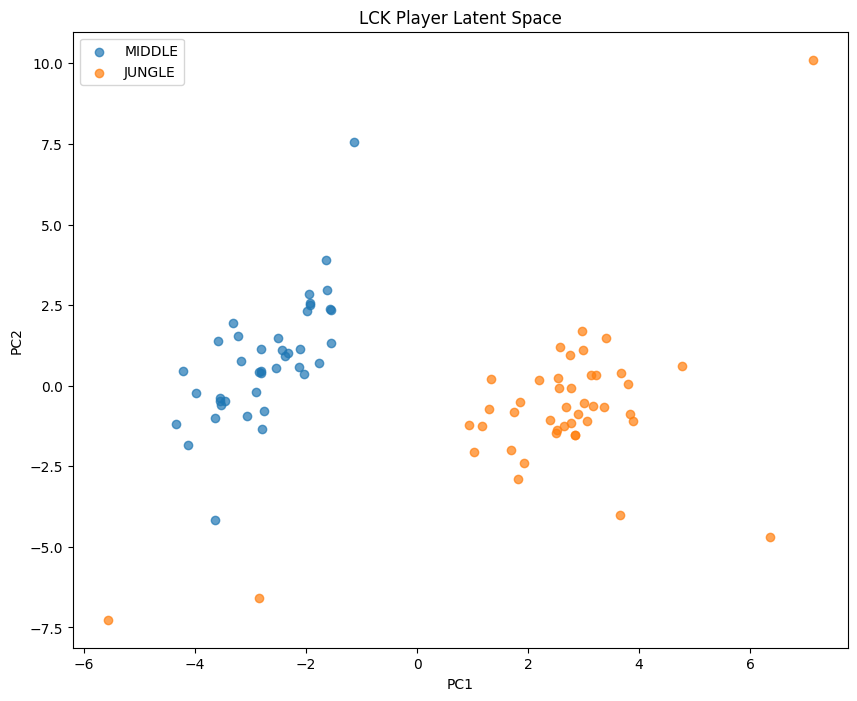

In [36]:
import matplotlib.pyplot as plt

positions = player_vectors["position"].unique()

plt.figure(figsize=(10,8))

for pos in positions:

    idx = (
        player_vectors["position"]
        == pos
    )

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=pos,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "LCK Player Latent Space"
)

plt.legend()

plt.show()

#### Step 5. PCA loading
->PCA1, PCA2가 각각 의미하는게 뭔데...

In [37]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_features
)

print(loadings)

                                  PC1       PC2
kills                        0.147629  0.259084
deaths                       0.085799  0.040403
assists                      0.244267  0.157301
doubleKills                  0.045344  0.019792
tripleKills                 -0.025315  0.075261
quadraKills                 -0.066166  0.060386
pentaKills                  -0.052963  0.035353
totalDamageDealtToChampions -0.054200  0.394156
totalDamageTaken             0.295081  0.031655
damageSelfMitigated          0.309489  0.031740
timeCCingOthers              0.150992  0.264217
visionScore                  0.288033  0.058577
wardsPlaced                 -0.007943  0.187462
wardsKilled                  0.259445  0.028758
visionWardsBoughtInGame      0.261165 -0.043770
goldEarned                   0.112479  0.385456
cs                          -0.152350  0.320402
champLevel                  -0.040195  0.389260
firstBloodKill               0.137453  0.075165
firstBloodAssist             0.053421 -0

### MID 선수들의 latent playstyle 분석

In [38]:
mid_data = player_vectors[
    player_vectors["position"] == "MIDDLE"
].copy()

#### Step 1. 미드 선수들 뽑아내기

In [39]:
print(mid_data.shape)

print(
    mid_data["playername"].unique()[:10]
)

(41, 32)
<StringArray>
[    'Bdd', 'BuLLDoG',   'Calix',   'Chovy',  'Clozer',    'FATE',   'Faker',
  'Fisher',   'Karis',    'Loki']
Length: 10, dtype: str


#### Step 2. MID feature matrix 생성

In [40]:
X_mid = mid_data[numeric_features]

#### STEP 3. Standardization

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_mid_scaled = scaler.fit_transform(X_mid)

#### STEP 4. MID 전용 PCA

In [42]:
from sklearn.decomposition import PCA

pca_mid = PCA(n_components=2)

X_mid_pca = pca_mid.fit_transform(
    X_mid_scaled
)

#### STEP 5. PCA 좌표 dataframe 생성

In [43]:
mid_data["PC1"] = X_mid_pca[:,0]
mid_data["PC2"] = X_mid_pca[:,1]

#### STEP 6. MID latent space 시각화

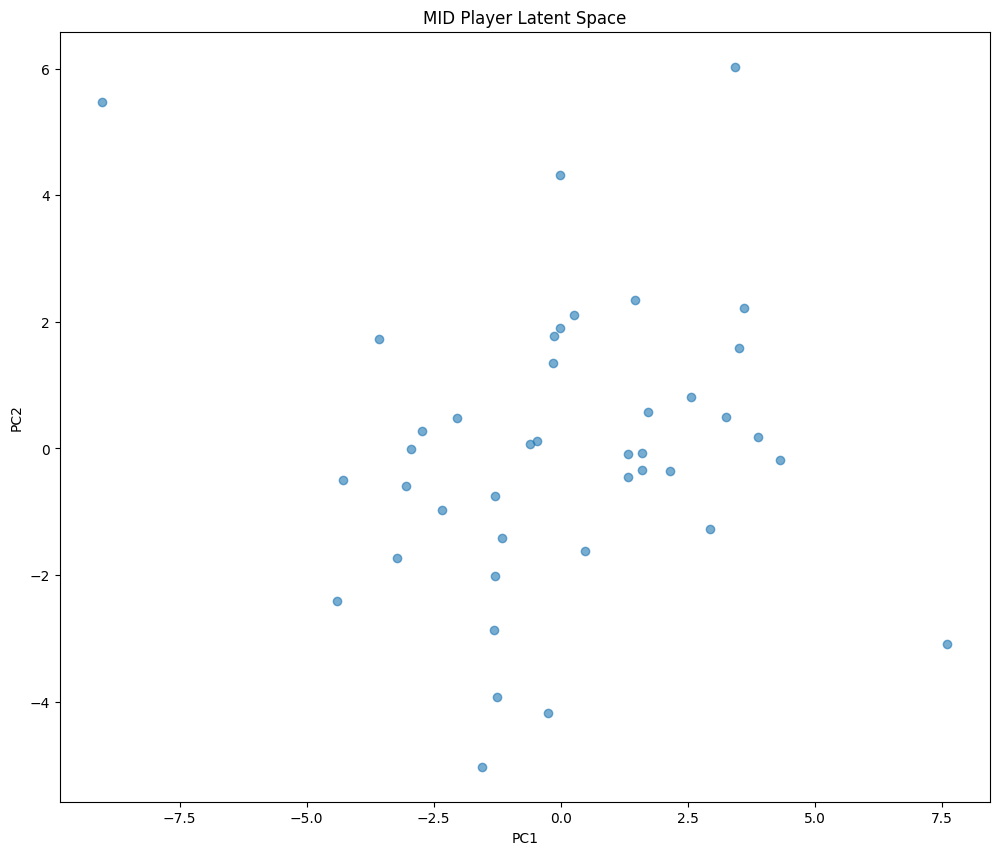

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.scatter(
    mid_data["PC1"],
    mid_data["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "MID Player Latent Space"
)

plt.show()

#### STEP 7. MID PCA loading 분석

In [64]:
# PCA Loading DataFrame 생성
loading_df = pd.DataFrame(
    pca_mid.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

# 절댓값 컬럼 추가
loading_df["PC1_abs"] = loading_df["PC1"].abs()
loading_df["PC2_abs"] = loading_df["PC2"].abs()

# PC1 기준 중요 feature 보기
# 양의 방향 TOP
print(
    loading_df.sort_values(
        by="PC1",
        ascending=False
    ).head(10)
)

# 음의 방향 TOP
print(
    loading_df.sort_values(
        by="PC1",
        ascending=True
    ).head(10)
)

                                  PC1       PC2   PC1_abs   PC2_abs
cs                           0.275621  0.082983  0.275621  0.082983
goldEarned                   0.272382 -0.025472  0.272382  0.025472
visionScore                  0.271358  0.068582  0.271358  0.068582
champLevel                   0.270401  0.101841  0.270401  0.101841
vspm                         0.251371  0.010807  0.251371  0.010807
cspm                         0.246751 -0.063548  0.246751  0.063548
earned_gpm                   0.239929 -0.195155  0.239929  0.195155
timeCCingOthers              0.235070  0.017697  0.235070  0.017697
totalDamageDealtToChampions  0.232436  0.035913  0.232436  0.035913
wardsPlaced                  0.227266  0.123849  0.227266  0.123849
                              PC1       PC2   PC1_abs   PC2_abs
deaths                  -0.162039  0.298078  0.162039  0.298078
tripleKills             -0.066566 -0.077114  0.066566  0.077114
quadraKills             -0.046578 -0.139880  0.046578  0.139

#### 미드 선수들의 PCA분산 해석

* 저런식으로 형성이 되어있는데 해석을 하면 이PC1 점수가 높은 선수일수록 게임 전체에 미치는 영향력이 큰 플레이어에 가까워짐 




### JGL 선수들의 Latent playstyle 분석

### Step 1. 정글 데이터만 추출

In [54]:
jng_data = player_vectors[
    player_vectors["position"] == "JUNGLE"
].copy()

#### Step 2. PCA 가능하게 Numeric Features만 추출

In [55]:
X_jng = jng_data[numeric_features]

#### Step 3. Standardization

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_jng_scaled = scaler.fit_transform(
    X_jng
)

#### Step 4. PCA 수행

In [57]:
from sklearn.decomposition import PCA

pca_jng = PCA(n_components=2)

X_jng_pca = pca_jng.fit_transform(
    X_jng_scaled
)

#### STEP 5. PCA 좌표 dataframe 생성

In [58]:
jng_data["PC1"] = X_jng_pca[:,0]
jng_data["PC2"] = X_jng_pca[:,1]

#### Step 6. JGL latent space 시각화

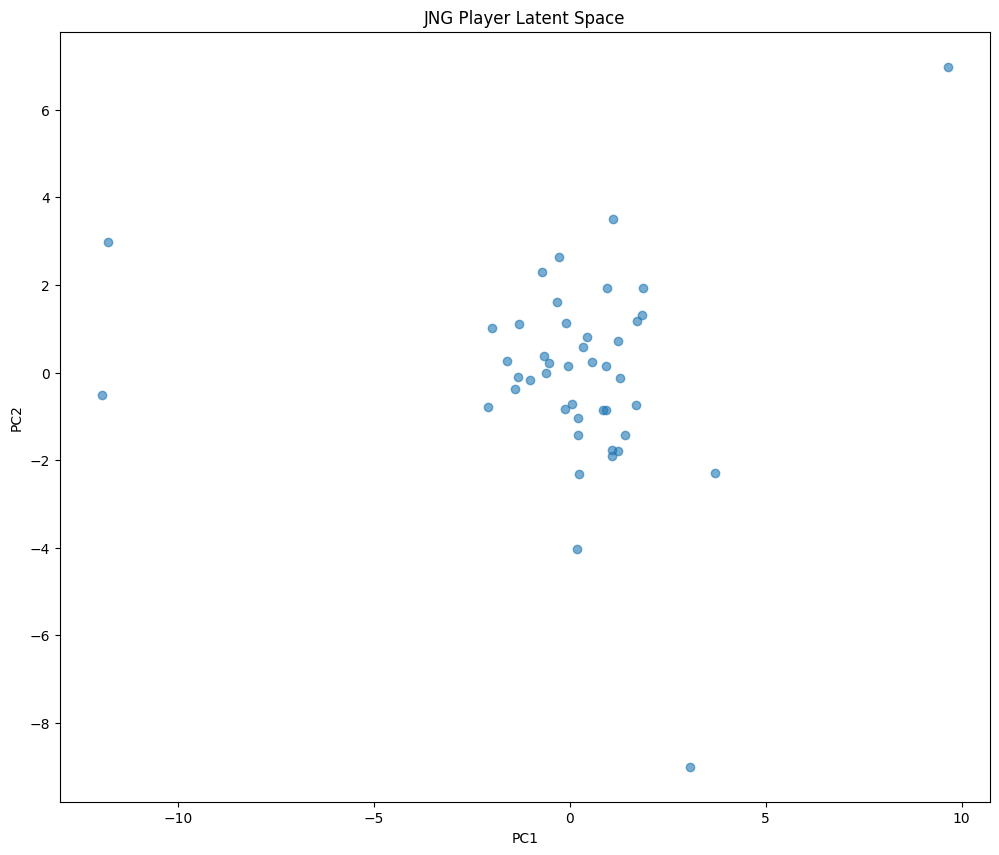

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.scatter(
    jng_data["PC1"],
    jng_data["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "JNG Player Latent Space"
)

plt.show()

#### Step 7. JGL PCA loading 분석

In [61]:
import pandas as pd

loadings_jng = pd.DataFrame(
    pca_jng.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_features
)
print(
    loadings_jng.sort_values(
        by="PC1",
        ascending=False
    )
)

                                  PC1       PC2
damageSelfMitigated          0.280097 -0.007567
totalDamageTaken             0.271789 -0.071470
totalDamageDealtToChampions  0.270542  0.190122
assists                      0.263024  0.112526
damagemitigatedperminute     0.254028 -0.054978
goldEarned                   0.253900  0.230083
visionScore                  0.242664 -0.083904
champLevel                   0.240893  0.201583
dpm                          0.237845  0.206736
deaths                       0.229980 -0.189465
timeCCingOthers              0.220541  0.158132
wardsKilled                  0.217051 -0.163135
damagetakenperminute         0.202029 -0.144872
cs                           0.177653  0.227770
wcpm                         0.170605 -0.194934
firstBloodKill               0.167408 -0.178973
kills                        0.151711  0.330938
wardsPlaced                  0.134190 -0.132285
visionWardsBoughtInGame      0.125193 -0.141341
vspm                         0.124017 -0